# Приоритизация клиентов для банковского обзвона

Я хочу решить не абстрактную задачу «предсказать `yes`», а помочь колл-центру выбрать клиентов для следующей кампании.

**Один объект:** клиент перед очередным звонком.  
**Класс 1:** клиент оформил срочный вклад.  
**Момент прогноза:** до звонка.  
**Ограничение:** связаться можно только с 10% клиентов.  
**Результат:** ранжированный список клиентов для обзвона.

Основная техническая метрика — Average Precision. Бизнес-результат проверяю через `Precision@K`, `Recall@K` и `Lift@K`.

## 1. Загрузка данных

Использую полный `bank-additional-full.csv`: 41 188 наблюдений вместо учебной 10%-ной выборки. Данные взяты из [UCI Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank%2Bmarketing).

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent

data_path = project_root / "data" / "raw" / "bank-additional-full.csv"
data = pd.read_csv(data_path, sep=";")

print("Размер данных:", data.shape)
display(data.head(3))

Размер данных: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


В таблице 41 188 строк и 21 столбец: 20 признаков и целевая переменная `y`. Этого достаточно, чтобы оценивать модели не на маленьком учебном фрагменте, а на полном наборе.

## 2. Проверка target и признаков

`duration` показывает длительность уже состоявшегося звонка. До звонка этот признак неизвестен, поэтому я удаляю его как утечку из будущего.

В `pdays` значение `999` означает, что с клиентом раньше не связывались. Я отделяю этот случай от количества дней, чтобы модель не воспринимала его как очень большой срок.

In [2]:
target = data["y"].map({"no": 0, "yes": 1})
features = data.drop(columns=["y", "duration"])

features["was_previously_contacted"] = features["pdays"].ne(999).astype(int)
features["days_since_previous_contact"] = features["pdays"].where(
    features["pdays"].ne(999),
    0,
)
features = features.drop(columns="pdays")

target_summary = pd.DataFrame({
    "count": target.value_counts().sort_index(),
    "share": target.value_counts(normalize=True).sort_index(),
})

print("Используемых признаков:", features.shape[1])
print("duration удалён:", "duration" not in features.columns)
print("pdays преобразован:", "pdays" not in features.columns)
print("Пропущенных значений:", int(data.isna().sum().sum()))
print("Полных дублей:", int(data.duplicated().sum()))
display(target_summary)

Используемых признаков: 20
duration удалён: True
pdays преобразован: True
Пропущенных значений: 0
Полных дублей: 12


,count,share
y,,
0,36548,0.887346
1,4640,0.112654


Положительный класс встречается заметно реже отрицательного. Поэтому accuracy не использую как основную метрику: модель могла бы почти всегда отвечать `0` и выглядеть точной.

## 3. Финальное разбиение


In [3]:
split_index = int(len(data) * 0.80)

X_dev = features.iloc[:split_index].copy()
y_dev = target.iloc[:split_index].copy()

X_test = features.iloc[split_index:].copy()
y_test = target.iloc[split_index:].copy()

split_summary = pd.DataFrame({
    "rows": [len(X_dev), len(X_test)],
    "positive_rate": [y_dev.mean(), y_test.mean()],
}, index=["development", "test"])

cross_split_duplicates = (
    data.iloc[:split_index]
    .merge(
        data.iloc[split_index:],
        on=data.columns.tolist(),
        how="inner",
    )
    .shape[0]
)

display(split_summary)
print("Полных дублей между development и test:", cross_split_duplicates)

,rows,positive_rate
development,32950,0.063733
test,8238,0.308327


Полных дублей между development и test: 0


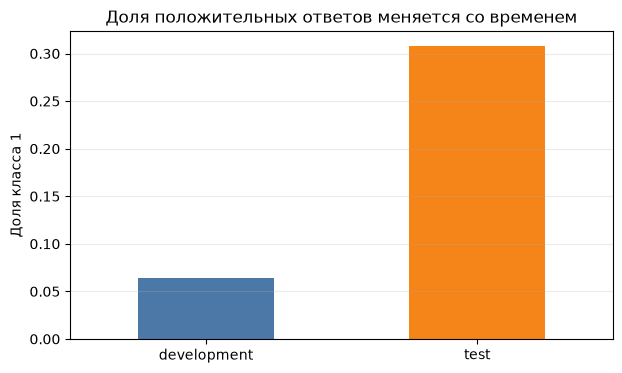

In [4]:
split_summary["positive_rate"].plot(
    kind="bar",
    color=["#4C78A8", "#F58518"],
    figsize=(7, 4),
)
plt.title("Доля положительных ответов меняется со временем")
plt.ylabel("Доля класса 1")
plt.xlabel("")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.show()

В поздней части данных положительных ответов намного больше. Значит, кампании отличаются по условиям и поведению клиентов. Для меня это важный результат: случайное перемешивание скрыло бы этот сдвиг.

В полном файле есть 12 одинаковых строк, но ни одна не пересекает development и test. Я не удаляю их: без идентификатора клиента нельзя понять, это технический дубль или два клиента с одинаковыми значениями. На итог при таком количестве они практически не влияют.

## 4. Preprocessing внутри Pipeline

Сохраняю схему универсального шаблона: числовые и категориальные признаки обрабатываются внутри `Pipeline`, чтобы преобразования обучались отдельно на каждом фолде.

In [5]:
numeric_features = X_dev.select_dtypes(include="number").columns.tolist()
categorical_features = X_dev.select_dtypes(exclude="number").columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

print("Числовых признаков:", len(numeric_features))
print("Категориальных признаков:", len(categorical_features))

Числовых признаков: 10
Категориальных признаков: 10


## 5. Временная кросс-валидация

Доля класса 1 между периодами меняется, а AP зависит от этой доли. Поэтому дополнительно считаю `AP lift = AP / доля класса 1`. Значение больше 1 означает, что ранжирование лучше случайного.

In [6]:
cv = TimeSeriesSplit(n_splits=5)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        solver="liblinear",
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=50,
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=20,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

## 6. Сравнение моделей

Стандартный `cross_validate` не считает baseline AP каждого временного фолда. Поэтому здесь использую явный цикл: обучаю модель на прошлом, получаю вероятности на следующем периоде и сохраняю метрики.

In [7]:
fold_rows = []

for model_name, estimator in models.items():
    for fold, (train_index, valid_index) in enumerate(cv.split(X_dev), start=1):
        candidate = Pipeline(steps=[
            ("preprocessor", clone(preprocessor)),
            ("model", clone(estimator)),
        ])

        X_train_fold = X_dev.iloc[train_index]
        y_train_fold = y_dev.iloc[train_index]
        X_valid_fold = X_dev.iloc[valid_index]
        y_valid_fold = y_dev.iloc[valid_index]

        candidate.fit(X_train_fold, y_train_fold)

        train_proba = candidate.predict_proba(X_train_fold)[:, 1]
        valid_proba = candidate.predict_proba(X_valid_fold)[:, 1]

        train_ap = average_precision_score(y_train_fold, train_proba)
        valid_ap = average_precision_score(y_valid_fold, valid_proba)

        fold_rows.append({
            "model": model_name,
            "fold": fold,
            "train_ap_lift": train_ap / y_train_fold.mean(),
            "valid_ap": valid_ap,
            "valid_ap_lift": valid_ap / y_valid_fold.mean(),
            "valid_roc_auc": roc_auc_score(y_valid_fold, valid_proba),
        })

fold_results = pd.DataFrame(fold_rows)

comparison = (
    fold_results
    .groupby("model")
    .agg(
        train_ap_lift_mean=("train_ap_lift", "mean"),
        cv_ap_mean=("valid_ap", "mean"),
        cv_ap_lift_mean=("valid_ap_lift", "mean"),
        cv_ap_lift_std=("valid_ap_lift", "std"),
        cv_roc_auc_mean=("valid_roc_auc", "mean"),
    )
)

comparison["overfit_gap_lift"] = (
    comparison["train_ap_lift_mean"]
    - comparison["cv_ap_lift_mean"]
)

comparison = comparison.sort_values(
    "cv_ap_lift_mean",
    ascending=False,
)

display(comparison.round(3))

,train_ap_lift_mean,cv_ap_mean,cv_ap_lift_mean,cv_ap_lift_std,cv_roc_auc_mean,overfit_gap_lift
model,,,,,,
Logistic Regression,1.797,0.085,1.129,0.201,0.535,0.668
Random Forest,4.600,0.087,1.107,0.285,0.515,3.493
Decision Tree,1.779,0.072,1.020,0.050,0.503,0.760


Random Forest немного выигрывает по обычному CV AP, но его результат сильнее меняется между периодами и разрыв с train намного больше. Logistic Regression даёт лучший средний AP lift и ROC-AUC, поэтому я выбираю её как более устойчивую и понятную модель.

## 7. Фиксация модели и Top-K политики

Модель зафиксирована до просмотра test. В этой задаче мне не нужен порог вроде `0.5`: число звонков уже ограничено. Я сортирую клиентов по вероятности и беру верхние 10%.

Временные фолды соответствуют разным периодам, поэтому Top-K считаю отдельно внутри каждого фолда, а затем объединяю результаты. Смешивать вероятности разных периодов в один общий рейтинг было бы некорректно.

In [8]:
final_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("model", clone(models["Logistic Regression"])),
])

budget_shares = [0.05, 0.10, 0.20]


def top_k_metrics(y_true, scores, budget_share):
    y_true = pd.Series(y_true).reset_index(drop=True)
    scores = np.asarray(scores)

    k = int(np.ceil(len(y_true) * budget_share))
    selected_index = np.argsort(-scores)[:k]
    selected_actual = y_true.iloc[selected_index]

    return {
        "budget_share": budget_share,
        "calls": k,
        "successes": int(selected_actual.sum()),
        "total_positives": int(y_true.sum()),
        "precision_at_k": selected_actual.mean(),
        "recall_at_k": selected_actual.sum() / y_true.sum(),
        "lift_at_k": selected_actual.mean() / y_true.mean(),
        "random_expected_successes": k * y_true.mean(),
    }

In [9]:
policy_rows = []

for fold, (train_index, valid_index) in enumerate(cv.split(X_dev), start=1):
    fold_model = clone(final_pipeline)
    fold_model.fit(X_dev.iloc[train_index], y_dev.iloc[train_index])

    valid_proba = fold_model.predict_proba(X_dev.iloc[valid_index])[:, 1]
    y_valid_fold = y_dev.iloc[valid_index]

    for budget_share in budget_shares:
        row = top_k_metrics(y_valid_fold, valid_proba, budget_share)
        row["fold"] = fold
        policy_rows.append(row)

validation_policy = pd.DataFrame(policy_rows)

validation_summary = (
    validation_policy
    .groupby("budget_share")
    .agg(
        calls=("calls", "sum"),
        successes=("successes", "sum"),
        total_positives=("total_positives", "sum"),
        random_expected_successes=("random_expected_successes", "sum"),
    )
    .reset_index()
)

validation_summary["precision_at_k"] = (
    validation_summary["successes"] / validation_summary["calls"]
)
validation_summary["recall_at_k"] = (
    validation_summary["successes"] / validation_summary["total_positives"]
)
validation_summary["lift_at_k"] = (
    validation_summary["successes"]
    / validation_summary["random_expected_successes"]
)

display(validation_summary.round(3))

,budget_share,calls,successes,total_positives,random_expected_successes,precision_at_k,recall_at_k,lift_at_k
0,0.05,1375,85,1939,97.109,0.062,0.044,0.875
1,0.10,2750,258,1939,194.218,0.094,0.133,1.328
2,0.20,5495,507,1939,388.082,0.092,0.261,1.306


На временной валидации эффект нестабилен между периодами, но при бюджете 10% суммарный результат остаётся лучше случайного выбора. Это честнее, чем показывать только один удачный случайный split.

## 8. Обучение на всех development data

После выбора модели и политики обучаю один pipeline на всей доступной истории. До этого момента финальный test не использовался.

In [10]:
final_pipeline.fit(X_dev, y_dev)
test_proba = final_pipeline.predict_proba(X_test)[:, 1]

test_metrics = pd.Series({
    "AP": average_precision_score(y_test, test_proba),
    "AP baseline": y_test.mean(),
    "AP lift": average_precision_score(y_test, test_proba) / y_test.mean(),
    "ROC-AUC": roc_auc_score(y_test, test_proba),
})

display(test_metrics.round(3).to_frame("value"))

,value
AP,0.530
AP baseline,0.308
AP lift,1.718
ROC-AUC,0.745


## 9. Бизнес-результат на финальном test

Теперь один раз проверяю, сколько положительных ответов получает колл-центр при разных размерах списка.

In [11]:
test_policy = pd.DataFrame([
    top_k_metrics(y_test, test_proba, budget_share)
    for budget_share in budget_shares
])

display(test_policy.round(3))

,budget_share,calls,successes,total_positives,precision_at_k,recall_at_k,lift_at_k,random_expected_successes
0,0.05,412,241,2540,0.585,0.095,1.897,127.031
1,0.10,824,484,2540,0.587,0.191,1.905,254.062
2,0.20,1648,982,2540,0.596,0.387,1.933,508.123


In [12]:
main_policy = test_policy.loc[
    test_policy["budget_share"].eq(0.10)
].iloc[0]

print(f"Клиентов в test: {len(y_test):,}".replace(",", " "))
print(f"Звонков при бюджете 10%: {int(main_policy['calls'])}")
print(f"Положительных ответов: {int(main_policy['successes'])}")
print(
    "Ожидаемо при случайном выборе: "
    f"{main_policy['random_expected_successes']:.0f}"
)
print(f"Precision@10%: {main_policy['precision_at_k']:.1%}")
print(f"Recall@10%: {main_policy['recall_at_k']:.1%}")
print(f"Lift@10%: {main_policy['lift_at_k']:.2f}")

Клиентов в test: 8 238
Звонков при бюджете 10%: 824
Положительных ответов: 484
Ожидаемо при случайном выборе: 254
Precision@10%: 58.7%
Recall@10%: 19.1%
Lift@10%: 1.91


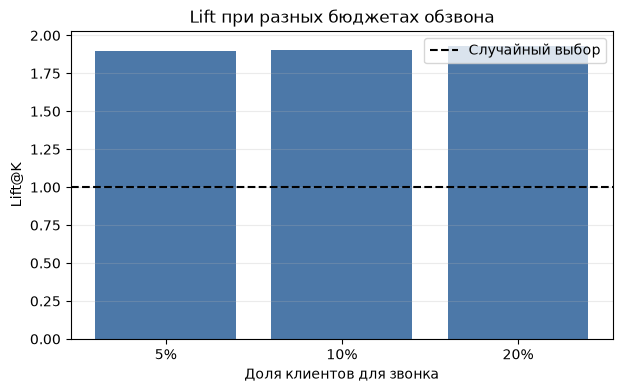

In [13]:
plt.figure(figsize=(7, 4))
plt.bar(
    (test_policy["budget_share"] * 100).astype(int).astype(str) + "%",
    test_policy["lift_at_k"],
    color="#4C78A8",
)
plt.axhline(1, color="black", linestyle="--", label="Случайный выбор")
plt.title("Lift при разных бюджетах обзвона")
plt.xlabel("Доля клиентов для звонка")
plt.ylabel("Lift@K")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()

При бюджете 10% модель выбирает 824 клиента и находит 484 положительных ответа. При случайном выборе ожидалось бы около 254. Полученный `Lift@10% ≈ 1.91` означает почти двукратное увеличение эффективности списка для обзвона.

## 10. Проверка сегментов

Я не использую сегменты как доказательство причин. Этот отчёт нужен, чтобы увидеть, не концентрирует ли модель почти весь список в одной группе и нет ли явно странного поведения.

In [14]:
test_results = X_test[["job"]].copy()
test_results["actual"] = y_test.to_numpy()
test_results["score"] = test_proba

top_10_count = int(main_policy["calls"])
selected_rows = test_results.nlargest(top_10_count, "score").index
test_results["selected_top_10"] = test_results.index.isin(selected_rows)

segment_report = (
    test_results
    .groupby("job")
    .agg(
        clients=("actual", "size"),
        actual_response_rate=("actual", "mean"),
        average_score=("score", "mean"),
        selected_share=("selected_top_10", "mean"),
    )
    .sort_values("clients", ascending=False)
)

display(segment_report.round(3))

,clients,actual_response_rate,average_score,selected_share
job,,,,
admin.,2382,0.333,0.247,0.097
blue-collar,1295,0.167,0.125,0.024
technician,1166,0.323,0.242,0.096
retired,730,0.440,0.398,0.247
services,644,0.225,0.159,0.053
student,528,0.407,0.388,0.208
management,524,0.323,0.245,0.090
self-employed,265,0.257,0.222,0.087
unemployed,265,0.381,0.277,0.102


## 11. Интерпретация признаков

Permutation importance показывает, насколько падает AP после перемешивания одного исходного признака. Для скорости считаю её на фиксированной выборке из 2 000 объектов test.

Знак коэффициента Logistic Regression показывает направление связи со score модели. Положительный коэффициент связан с более высоким score, отрицательный — с более низким.

In [15]:
importance_sample = X_test.sample(
    n=min(2000, len(X_test)),
    random_state=RANDOM_STATE,
)
importance_target = y_test.loc[importance_sample.index]

importance = permutation_importance(
    estimator=final_pipeline,
    X=importance_sample,
    y=importance_target,
    scoring="average_precision",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

importance_table = pd.DataFrame({
    "feature": importance_sample.columns,
    "importance_mean": importance.importances_mean,
    "importance_std": importance.importances_std,
}).sort_values("importance_mean", ascending=False)

feature_names = final_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients = final_pipeline.named_steps["model"].coef_[0]

coefficient_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
})
coefficient_table["feature"] = (
    coefficient_table["feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

top_coefficients = pd.concat([
    coefficient_table.nsmallest(5, "coefficient"),
    coefficient_table.nlargest(5, "coefficient"),
]).sort_values("coefficient", ascending=False)

display(importance_table.head(8).round(4))
display(top_coefficients.round(3))

,feature,importance_mean,importance_std
18,was_previously_contacted,0.1359,0.0076
8,month,0.0427,0.0117
17,nr.employed,0.0415,0.0037
13,emp.var.rate,0.0208,0.0061
14,cons.price.idx,0.0136,0.0016
1,job,0.0057,0.0030
9,day_of_week,0.0027,0.0022
7,contact,0.0022,0.0009


,feature,coefficient
53,month_oct,1.640
6,euribor3m,1.035
50,month_mar,0.645
15,job_retired,0.439
30,education_illiterate,0.422
44,contact_telephone,-0.517
59,poutcome_failure,-0.548
51,month_may,-0.923
3,emp.var.rate,-0.970
52,month_nov,-1.098


Сильнее всего модель опирается на факт предыдущего контакта, месяц кампании и экономический контекст. Среди отдельных коэффициентов более высокий score связан с октябрём и мартом, более низкий — с маем, ноябрём и ростом `emp.var.rate`.

Эти связи описывают логику модели, а не причинное влияние на клиента. Поэтому я использую их для проверки здравого смысла и не считаю месяц или экономический показатель прямым способом изменить решение клиента.

## 12. Сохранение результата

Сохраняю весь pipeline и готовый ранжированный список. В реальной работе колл-центр получил бы именно список, а не отдельный класс `0/1`.

In [16]:
models_dir = project_root / "models"
outputs_dir = project_root / "outputs"
models_dir.mkdir(exist_ok=True)
outputs_dir.mkdir(exist_ok=True)

model_path = models_dir / "bank_marketing_pipeline.joblib"
ranking_path = outputs_dir / "top_10_clients.csv"

joblib.dump(final_pipeline, model_path)

ranked_clients = X_test.copy()
ranked_clients.insert(0, "source_row", ranked_clients.index)
ranked_clients["score"] = test_proba
ranked_clients = ranked_clients.nlargest(top_10_count, "score")
ranked_clients.to_csv(ranking_path, index=False)

print("Модель:", model_path.relative_to(project_root))
print("Список клиентов:", ranking_path.relative_to(project_root))

Модель: models\bank_marketing_pipeline.joblib
Список клиентов: outputs\top_10_clients.csv


## Итог

Я построил модель не ради максимальной метрики, а под конкретное ограничение колл-центра.

Logistic Regression оказалась разумнее более сложных моделей: на CV она была устойчивее Random Forest, а на финальном периоде дала `AP = 0.530`, `ROC-AUC = 0.745` и `Lift@10% = 1.91`.

Ограничения проекта: данные относятся к кампаниям 2008–2010 годов, в них нет идентификатора клиента и точной стоимости звонка. Поэтому я показываю метод оценки списка, но не переношу полученные цифры на современные кампании и не рассчитываю денежную прибыль.